# Stage 6b — Contact Detector

Everything before this assumed the contact frame was handed to you. In deployment nothing does. This is the actual *detect shots* problem, and it is a separate model from the classifier.

### Task

Given a continuous pose stream, emit a per-frame probability that a racket-ball contact occurs, then decode discrete contact times from it.

### Two design choices that matter

**Full temporal resolution — no downsampling.** A U-Net style encoder/decoder would be the obvious architecture, but every stride-2 layer blurs peak location, and this model is scored at **±5 frames (±42 ms)**. The stack stays at full resolution and uses dilation alone to reach a receptive field of ~1,000 frames.

**Soft Gaussian targets, not hard one-hot.** A contact is annotated on a single frame, but the source paper notes the exact impact moment is not always captured even at 120 fps, so the true instant carries roughly ±1 frame of noise. A hard target punishes a prediction one frame early exactly as hard as one 50 frames early. A Gaussian target (σ = 2) encodes that near-misses are nearly right, and it converts an impossibly sparse target — 1 in 139 frames — into something trainable without resampling, which would destroy the temporal continuity the model depends on.

### Two heads

| head | positives | purpose |
|---|---|---|
| `contact` | 1,576 | any racket-ball impact |
| `side` | 1,457 | which player struck it — masked where unknown |

The 119 `empty_event` markers are untyped, so they train the contact head but are masked out of the side head. Attribution comes free and feeds Phase 2 rally counting.

### Target

**F1 ≥ 0.85 at ±5 frames**, with peak-picking and NMS at a 0.25 s minimum inter-stroke gap.

GPU required. ~20 min.


## 1 · Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2 · Setup

In [ ]:
BASE = "/content/drive/MyDrive/tt_coach"

WINDOW   = 512      # training window in frames (~4.3 s at 120 fps)
SIGMA    = 2.0      # Gaussian target width, frames
TOL      = 5        # evaluation tolerance, frames (+/- 42 ms)
NMS_GAP  = 30       # min frames between contacts (0.25 s)
EPOCHS   = 40
BATCH    = 16
LR       = 2e-3
SEED     = 42

import json, math, random, warnings
from pathlib import Path
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
warnings.filterwarnings("ignore")

BASE   = Path(BASE); META = BASE/"derived/meta"; STREAM = BASE/"derived/pose_stream"
OUT    = BASE/"outputs"; (OUT/"metrics").mkdir(parents=True, exist_ok=True)
(OUT/"figures").mkdir(parents=True, exist_ok=True)

dev = "cuda" if torch.cuda.is_available() else "cpu"
assert dev == "cuda", "No GPU. Runtime > Change runtime type > T4."
def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
seed_all(SEED)

def load(stem):
    p = META/f"{stem}.parquet"
    return pd.read_parquet(p) if p.exists() else pd.read_csv(META/f"{stem}.csv")

strokes = load("strokes")
folds   = json.loads((META/"folds.json").read_text())
V2F     = folds["video2fold"]
VIDEO_IDS = sorted(strokes.video_id.unique(),
                   key=lambda v: (v.split("_")[0], int(v.split("_")[1])))

# side lookup for typed strokes: 0 = left player struck, 1 = right
SIDE = {(r.video_id, int(r.frame_120)): (0 if r.side == "left" else 1)
        for r in strokes.itertuples()}

L_SHO, R_SHO, L_WRI, R_WRI, L_HIP, R_HIP = 5, 6, 9, 10, 11, 12
FLIP_PAIRS = [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]
print(f"device {torch.cuda.get_device_name(0)}  |  {len(VIDEO_IDS)} videos")

device Tesla T4  |  12 videos


## 3 · Canonicalise the stream

Same normalisation as Stage 3 — hip-centred, torso-scaled — applied per frame instead of per stroke, so the detector sees the same geometry the classifier does.

Torso length is taken as a **per-segment median** rather than per-frame: a single bad frame would otherwise rescale that frame's entire skeleton and inject a spike exactly where the model is looking for one.

The right-hand player is mirrored so both are in a common frame, which halves what the network must learn about orientation.

In [ ]:
def canon_stream(kp, sc, seg_id, mirror):
    """kp (F,17,2) -> hip-centred, torso-scaled, optionally mirrored."""
    kp = kp.astype(np.float32).copy()
    hip = (kp[:, L_HIP] + kp[:, R_HIP]) / 2
    sho = (kp[:, L_SHO] + kp[:, R_SHO]) / 2
    torso = np.linalg.norm(sho - hip, axis=-1)

    scale = np.ones(len(kp), np.float32)
    for s in np.unique(seg_id):                  # per-segment median torso
        m = seg_id == s
        t = torso[m]; t = t[t > 1]
        scale[m] = np.median(t) if len(t) else 1.0
    scale = np.maximum(scale, 1e-3)

    kp = (kp - hip[:, None, :]) / scale[:, None, None]
    if mirror:
        kp[..., 0] *= -1
        for a, b in FLIP_PAIRS:
            kp[:, [a, b]] = kp[:, [b, a]]
            sc = sc.copy(); sc[:, [a, b]] = sc[:, [b, a]]
    return kp, sc


DATA = {}
for v in VIDEO_IDS:
    p = STREAM/f"{v}.npz"
    if not p.exists():
        print(f"  {v}: missing"); continue
    d = np.load(p, allow_pickle=True)
    fidx, seg = d["frame_idx"], d["seg_id"]
    KP, SC, DET = d["keypoints"], d["scores"], d["detected"]

    chans = []
    for pi in (0, 1):
        kp, sc = canon_stream(KP[:, pi], SC[:, pi].astype(np.float32),
                              seg, mirror=(pi == 1))
        vel = np.zeros_like(kp); vel[1:] = np.diff(kp, axis=0)
        vel[np.diff(seg, prepend=seg[0]) != 0] = 0      # no velocity across cuts
        chans += [kp.reshape(len(kp), -1), vel.reshape(len(kp), -1),
                  (sc * DET[:, pi:pi+1]).astype(np.float32)]
    X = np.nan_to_num(np.concatenate(chans, 1).astype(np.float32))

    # targets
    yc = np.zeros(len(fidx), np.float32)          # contact (soft)
    ys = np.full(len(fidx), -1.0, np.float32)     # side, -1 = unknown
    pos = np.where(d["is_contact"])[0]
    t = np.arange(len(fidx))
    for i in pos:
        lo, hi = max(0, i-4*int(SIGMA)), min(len(fidx), i+4*int(SIGMA)+1)
        yc[lo:hi] = np.maximum(yc[lo:hi],
                               np.exp(-((t[lo:hi]-i)**2)/(2*SIGMA**2)))
        s = SIDE.get((v, int(fidx[i])))
        if s is not None:
            ys[max(0, i-2):i+3] = s

    DATA[v] = dict(X=X, yc=yc, ys=ys, seg=seg, fidx=fidx,
                   pos=pos, fold=V2F[v])
    print(f"  {v}: {X.shape[0]:,} frames x {X.shape[1]} ch, "
          f"{len(pos)} contacts")

C_IN = next(iter(DATA.values()))["X"].shape[1]
eff  = np.mean([ (d["yc"] > 0.05).mean() for d in DATA.values() ])
print(f"\nC_IN={C_IN}   effective positive rate after smoothing: {eff:.4f}")
print(f"pos_weight will be ~{(1-eff)/eff:.0f}")

  game_1: 20,144 frames x 170 ch, 180 contacts
  game_2: 70,873 frames x 170 ch, 468 contacts
  game_3: 27,911 frames x 170 ch, 167 contacts
  game_4: 24,249 frames x 170 ch, 173 contacts
  game_5: 34,004 frames x 170 ch, 252 contacts
  test_1: 8,027 frames x 170 ch, 85 contacts
  test_2: 2,806 frames x 170 ch, 29 contacts
  test_3: 4,070 frames x 170 ch, 29 contacts
  test_4: 13,251 frames x 170 ch, 76 contacts
  test_5: 3,862 frames x 170 ch, 29 contacts
  test_6: 5,335 frames x 170 ch, 39 contacts
  test_7: 5,760 frames x 170 ch, 49 contacts

C_IN=170   effective positive rate after smoothing: 0.0699
pos_weight will be ~13


## 4 · Windowing

Windows are sampled **inside segments only** — a window spanning a segment boundary would contain a discontinuity the model could learn to fire on. Segments shorter than `WINDOW` are edge-padded and masked.

In [ ]:
def seg_spans(seg):
    """-> list of (start, end_exclusive) index spans for each segment."""
    cuts = np.where(np.diff(seg) != 0)[0] + 1
    b = np.concatenate([[0], cuts, [len(seg)]])
    return [(int(b[i]), int(b[i+1])) for i in range(len(b)-1)]

for v, d in DATA.items():
    d["spans"] = seg_spans(d["seg"])


def sample_window(d, rng):
    s, e = d["spans"][rng.integers(len(d["spans"]))]
    n = e - s
    if n <= WINDOW:
        sl = slice(s, e); pad = WINDOW - n
    else:
        st = s + rng.integers(n - WINDOW + 1)
        sl = slice(st, st + WINDOW); pad = 0
    X  = d["X"][sl]; yc = d["yc"][sl]; ys = d["ys"][sl]
    m  = np.ones(len(X), np.float32)
    if pad:
        X  = np.pad(X,  ((0, pad), (0, 0)), mode="edge")
        yc = np.pad(yc, (0, pad)); ys = np.pad(ys, (0, pad), constant_values=-1)
        m  = np.pad(m,  (0, pad))
    return X.T, yc, ys, m


def batch(vids, rng, n=BATCH):
    Xs, ycs, yss, ms = [], [], [], []
    for _ in range(n):
        d = DATA[vids[rng.integers(len(vids))]]
        a, b, c, e = sample_window(d, rng)
        Xs.append(a); ycs.append(b); yss.append(c); ms.append(e)
    to = lambda a, dt: torch.tensor(np.stack(a), dtype=dt, device=dev)
    return (to(Xs, torch.float32), to(ycs, torch.float32),
            to(yss, torch.float32), to(ms, torch.float32))

print(f"segments per video: "
      f"{ {v: len(d['spans']) for v, d in list(DATA.items())[:4]} } ...")

segments per video: {'game_1': 28, 'game_2': 102, 'game_3': 48, 'game_4': 30} ...


## 5 · Model

Seven dilated blocks (1→64) at full temporal resolution. Receptive field ≈ 1,100 frames, wider than any training window, so every output frame sees its full rally context — while peak locations stay frame-exact.

In [ ]:
class Block(nn.Module):
    def __init__(s, c, d, drop=0.1):
        super().__init__()
        s.c1 = nn.Conv1d(c, c, 5, padding=2*d, dilation=d)
        s.c2 = nn.Conv1d(c, c, 5, padding=2*d, dilation=d)
        s.n1, s.n2 = nn.BatchNorm1d(c), nn.BatchNorm1d(c)
        s.do = nn.Dropout(drop)
    def forward(s, x):
        r = x
        x = s.do(F.gelu(s.n1(s.c1(x))))
        x = s.do(F.gelu(s.n2(s.c2(x))))
        return F.gelu(x + r)


class Detector(nn.Module):
    def __init__(s, c_in, w=128):
        super().__init__()
        s.stem = nn.Sequential(nn.Conv1d(c_in, w, 1), nn.BatchNorm1d(w), nn.GELU())
        s.blocks = nn.Sequential(*[Block(w, d) for d in (1,2,4,8,16,32,64)])
        s.head_c = nn.Conv1d(w, 1, 1)      # contact
        s.head_s = nn.Conv1d(w, 1, 1)      # side
    def forward(s, x):
        z = s.blocks(s.stem(x))
        return s.head_c(z).squeeze(1), s.head_s(z).squeeze(1)

rf = 1 + sum(2*2*(5-1)*d for d in (1,2,4,8,16,32,64))
print(f"params {sum(p.numel() for p in Detector(C_IN).parameters()):,}  |  "
      f"receptive field ~{rf} frames ({rf/120:.1f} s)")

params 1,174,658  |  receptive field ~2033 frames (16.9 s)


## 6 · Decoding & metric

A raw probability curve is not a set of contacts. Peaks are picked above a threshold, then non-maximum suppression enforces a 0.25 s minimum gap — you physically cannot strike twice faster than that.

Matching is **greedy by confidence**: the most confident prediction claims its nearest unmatched ground-truth contact within tolerance. This avoids the double-counting a naive nearest-neighbour match would allow.

In [ ]:
def decode(prob, thr, gap=NMS_GAP):
    """Probability curve -> contact frame indices, most-confident first."""
    idx = np.where(prob >= thr)[0]
    if not len(idx):
        return np.array([], int)
    peaks = [i for i in idx
             if prob[i] == prob[max(0, i-gap//2):i+gap//2+1].max()]
    peaks = sorted(peaks, key=lambda i: -prob[i])
    kept = []
    for p in peaks:
        if all(abs(p - k) >= gap for k in kept):
            kept.append(p)
    return np.array(sorted(kept), int)


def match(pred, true, tol=TOL):
    """-> tp, fp, fn, list of signed frame offsets for matched pairs."""
    used, offs, tp = set(), [], 0
    for p in pred:
        best, bd = None, tol + 1
        for j, t in enumerate(true):
            if j in used: continue
            dist = abs(p - t)
            if dist <= tol and dist < bd:
                best, bd = j, dist
        if best is not None:
            used.add(best); tp += 1; offs.append(int(p - true[best]))
    return tp, len(pred) - tp, len(true) - tp, offs


def prf(tp, fp, fn):
    p = tp / max(tp + fp, 1); r = tp / max(tp + fn, 1)
    return p, r, 2 * p * r / max(p + r, 1e-9)

print("decoder ready")

decoder ready


## 7 · Train (7-fold LOVO)

In [ ]:
@torch.no_grad()
def infer(net, d):
    """Full-stream inference, segment by segment."""
    net.eval()
    prob = np.zeros(len(d["X"]), np.float32)
    side = np.zeros(len(d["X"]), np.float32)
    for s, e in d["spans"]:
        x = torch.tensor(d["X"][s:e].T[None], dtype=torch.float32, device=dev)
        lc, ls = net(x)
        prob[s:e] = torch.sigmoid(lc)[0].cpu().numpy()
        side[s:e] = torch.sigmoid(ls)[0].cpu().numpy()
    return prob, side


def run_fold(f, rng):
    tr = [v for v in DATA if DATA[v]["fold"] != f]
    va = [v for v in DATA if DATA[v]["fold"] == f]
    if not va: return None

    mu = np.concatenate([DATA[v]["X"] for v in tr]).mean(0)
    sd = np.concatenate([DATA[v]["X"] for v in tr]).std(0) + 1e-6
    for v in DATA: DATA[v]["Xn"] = (DATA[v]["X"] - mu) / sd
    for v in DATA: DATA[v]["X_backup"], DATA[v]["X"] = DATA[v]["X"], DATA[v]["Xn"]

    eff = np.mean([(DATA[v]["yc"] > 0.05).mean() for v in tr])
    pw = torch.tensor((1 - eff) / eff, device=dev)

    net = Detector(C_IN).to(dev)
    opt = torch.optim.AdamW(net.parameters(), lr=LR, weight_decay=1e-4)
    steps = EPOCHS * 40
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, LR, total_steps=steps)

    net.train()
    for _ in range(steps):
        x, yc, ys, m = batch(tr, rng)
        lc, ls = net(x)
        loss = (F.binary_cross_entropy_with_logits(
                    lc, yc, pos_weight=pw, reduction="none") * m).sum() / m.sum()
        sm = (ys >= 0).float() * m
        if sm.sum() > 0:
            loss = loss + 0.3 * (F.binary_cross_entropy_with_logits(
                ls, ys.clamp(min=0), reduction="none") * sm).sum() / sm.sum()
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        opt.step(); sch.step()

    out = {}
    for v in va:
        p, s = infer(net, DATA[v])
        out[v] = (p, s)
    for v in DATA: DATA[v]["X"] = DATA[v]["X_backup"]
    return out


seed_all(SEED); rng = np.random.default_rng(SEED)
PROB = {}
for f in sorted({d["fold"] for d in DATA.values()}):
    r = run_fold(f, rng)
    if r:
        PROB.update(r)
        print(f"  fold {f}: inferred {list(r)}")
print(f"\nOOF probability curves for {len(PROB)} videos")

  fold A: inferred ['game_1']
  fold B: inferred ['game_2']
  fold C: inferred ['game_3']
  fold D: inferred ['game_4']
  fold E: inferred ['game_5']
  fold F: inferred ['test_1', 'test_4']
  fold G: inferred ['test_2', 'test_3', 'test_5', 'test_6', 'test_7']

OOF probability curves for 12 videos


## 8 · Threshold sweep & results

The threshold is chosen on the OOF curves, which is a mild optimism — with 12 videos there is no clean third split, so treat the reported F1 as a slight upper bound.

In [ ]:
rows = []
for thr in np.arange(0.05, 0.96, 0.05):
    TP = FP = FN = 0
    for v, (p, _) in PROB.items():
        d = DATA[v]
        tp, fp, fn, _ = match(decode(p, thr), d["pos"])
        TP += tp; FP += fp; FN += fn
    pr, rc, f1 = prf(TP, FP, FN)
    rows.append(dict(thr=round(thr,2), precision=pr, recall=rc, f1=f1,
                     tp=TP, fp=FP, fn=FN))
sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

best = sweep.loc[sweep.f1.idxmax()]
THR = float(best.thr)
print(f"\n  best threshold {THR:.2f}  ->  F1 {best.f1:.3f} "
      f"(P {best.precision:.3f} / R {best.recall:.3f})")

per, offs_all = [], []
for v, (p, s) in PROB.items():
    d = DATA[v]
    pred = decode(p, THR)
    tp, fp, fn, offs = match(pred, d["pos"])
    pr, rc, f1 = prf(tp, fp, fn)
    offs_all += offs
    # side attribution on matched, typed contacts
    ok = tot = 0
    for q in pred:
        j = np.argmin(np.abs(d["pos"] - q)) if len(d["pos"]) else None
        if j is None or abs(d["pos"][j] - q) > TOL: continue
        truth = SIDE.get((v, int(d["fidx"][d["pos"][j]])))
        if truth is None: continue
        tot += 1; ok += int((s[q] >= 0.5) == bool(truth))
    per.append(dict(video_id=v, fold=d["fold"], n=len(d["pos"]),
                    tp=tp, fp=fp, fn=fn, precision=pr, recall=rc, f1=f1,
                    side_acc=ok/max(tot,1)))
pv = pd.DataFrame(per).sort_values("video_id")
pv.to_csv(OUT/"metrics/stage6_per_video.csv", index=False)
sweep.to_csv(OUT/"metrics/stage6_threshold_sweep.csv", index=False)
print("\n" + pv.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

TP, FP, FN = pv.tp.sum(), pv.fp.sum(), pv.fn.sum()
pr, rc, f1 = prf(TP, FP, FN)
offs = np.array(offs_all)
print("\n" + "=" * 72)
print(f"  contacts    : {int(pv.n.sum())}")
print(f"  TP/FP/FN    : {TP} / {FP} / {FN}")
print(f"  precision   : {pr:.3f}")
print(f"  recall      : {rc:.3f}")
print(f"  F1 @ +/-{TOL}  : {f1:.3f}   target >= 0.85  "
      f"{'PASS' if f1 >= 0.85 else 'BELOW TARGET'}")
print(f"  side acc    : {pv.side_acc.mean():.3f}")
if len(offs):
    print(f"\n  localisation: median {np.median(offs):+.1f} frames, "
          f"MAE {np.abs(offs).mean():.2f} frames "
          f"({np.abs(offs).mean()/120*1000:.0f} ms)")
    print(f"  within +/-1 frame: {(np.abs(offs)<=1).mean():.1%}")
print("=" * 72)

  thr  precision  recall    f1   tp  fp  fn
0.050      0.651   0.780 0.710 1230 660 346
0.100      0.699   0.775 0.735 1221 526 355
0.150      0.719   0.769 0.743 1212 473 364
0.200      0.739   0.766 0.752 1208 427 368
0.250      0.748   0.761 0.755 1200 404 376
0.300      0.759   0.757 0.758 1193 379 383
0.350      0.768   0.753 0.760 1187 359 389
0.400      0.779   0.750 0.764 1182 336 394
0.450      0.786   0.744 0.765 1173 319 403
0.500      0.797   0.741 0.768 1168 297 408
0.550      0.805   0.737 0.770 1162 282 414
0.600      0.820   0.736 0.776 1160 255 416
0.650      0.827   0.727 0.774 1146 240 430
0.700      0.836   0.720 0.774 1135 223 441
0.750      0.844   0.712 0.772 1122 208 454
0.800      0.854   0.701 0.770 1105 189 471
0.850      0.866   0.685 0.765 1079 167 497
0.900      0.877   0.658 0.752 1037 146 539
0.950      0.903   0.594 0.717  936 100 640

  best threshold 0.60  ->  F1 0.776 (P 0.820 / R 0.736)

video_id fold   n  tp  fp  fn  precision  recall    f1  side_a

## 9 · Tolerance curve

How much of the score depends on the tolerance being ±5? A curve that is still climbing steeply at 5 means the model finds contacts but localises them poorly; one that has flattened means the errors are genuine misses.

In [ ]:
rows = []
for tol in (1, 2, 3, 5, 8, 12, 20):
    TP = FP = FN = 0
    for v, (p, _) in PROB.items():
        tp, fp, fn, _ = match(decode(p, THR), DATA[v]["pos"], tol=tol)
        TP += tp; FP += fp; FN += fn
    pr, rc, f1 = prf(TP, FP, FN)
    rows.append(dict(tol_frames=tol, tol_ms=round(tol/120*1000),
                     precision=pr, recall=rc, f1=f1))
tc = pd.DataFrame(rows)
print(tc.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
tc.to_csv(OUT/"metrics/stage6_tolerance.csv", index=False)

f5  = float(tc.loc[tc.tol_frames == 5, "f1"].iloc[0])
f20 = float(tc.loc[tc.tol_frames == 20, "f1"].iloc[0])
print(f"\n  F1 at +/-5 {f5:.3f}  vs  +/-20 {f20:.3f}   gap {f20-f5:+.3f}")
if f20 - f5 > 0.08:
    print("  Sizeable gap: the model FINDS contacts but localises them loosely.")
    print("  Lower SIGMA (sharper targets) or raise the loss weight near peaks.")
else:
    print("  Small gap: localisation is tight; the remaining errors are")
    print("  genuine misses and false alarms, not timing slop.")

 tol_frames  tol_ms  precision  recall    f1
          1       8      0.392   0.352 0.370
          2      17      0.572   0.514 0.542
          3      25      0.685   0.615 0.648
          5      42      0.820   0.736 0.776
          8      67      0.886   0.796 0.839
         12     100      0.904   0.812 0.855
         20     167      0.916   0.822 0.867

  F1 at +/-5 0.776  vs  +/-20 0.867   gap +0.091
  Sizeable gap: the model FINDS contacts but localises them loosely.
  Lower SIGMA (sharper targets) or raise the loss weight near peaks.


## 10 · Inspect a rally

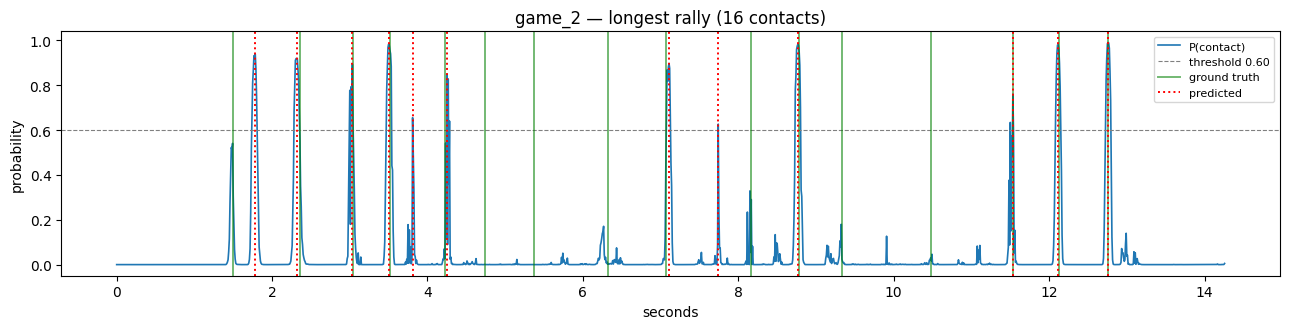

  16 true, 12 predicted -> tp 9, fp 3, fn 7
  offsets: [-5, -1, -2, 3, 5, -1, 0, -2, 0]


In [ ]:
import matplotlib.pyplot as plt

v = pv.sort_values("n", ascending=False).video_id.iloc[0]
d, (p, _) = DATA[v], PROB[v]
s0, e0 = max(d["spans"], key=lambda sp: ((d["pos"] >= sp[0]) &
                                         (d["pos"] < sp[1])).sum())
pred = decode(p, THR); pred = pred[(pred >= s0) & (pred < e0)]
true = d["pos"][(d["pos"] >= s0) & (d["pos"] < e0)]

fig, ax = plt.subplots(figsize=(13, 3.4))
t = (np.arange(s0, e0) - s0) / 120
ax.plot(t, p[s0:e0], lw=1.2, label="P(contact)")
ax.axhline(THR, ls="--", lw=0.8, c="grey", label=f"threshold {THR:.2f}")
for i, x in enumerate(true):
    ax.axvline((x-s0)/120, c="g", alpha=0.55, lw=1.4,
               label="ground truth" if i == 0 else None)
for i, x in enumerate(pred):
    ax.axvline((x-s0)/120, c="r", ls=":", lw=1.4,
               label="predicted" if i == 0 else None)
ax.set_xlabel("seconds"); ax.set_ylabel("probability")
ax.set_title(f"{v} — longest rally ({len(true)} contacts)")
ax.legend(loc="upper right", fontsize=8); plt.tight_layout()
plt.savefig(OUT/"figures/stage6_rally.png", dpi=130); plt.show()

tp, fp, fn, offs = match(pred, true)
print(f"  {len(true)} true, {len(pred)} predicted -> "
      f"tp {tp}, fp {fp}, fn {fn}")
if offs: print(f"  offsets: {offs}")

---
## Done

| artifact | purpose |
|---|---|
| `outputs/metrics/stage6_per_video.csv` | per-video precision / recall / F1 / side accuracy |
| `outputs/metrics/stage6_threshold_sweep.csv` | threshold selection |
| `outputs/metrics/stage6_tolerance.csv` | F1 vs tolerance |
| `outputs/figures/stage6_rally.png` | probability curve against ground truth |

**Read in this order:**

1. **F1 at ±5 frames vs the 0.85 target.**
2. **Precision vs recall.** Low precision means firing between strokes; low recall means missing them. They call for opposite fixes, so do not read F1 alone.
3. **The tolerance curve (cell 9).** This separates *finding* from *localising* — the two failure modes look identical in the headline number.
4. **The rally plot (cell 10).** Where extra peaks appear tells you what the model mistakes for a contact.

Next: **`07_eval_e2e.ipynb`** — cascade this detector into the Stage 5 classifier and measure end-to-end. Expect roughly `detection_F1 × classifier_F1`, so ~0.70 rather than 0.79.


In [11]:
# =============================================================================
# CELL 11 — MISS DIAGNOSTIC
#
# F1 @ +/-5 = 0.776 has TWO independent causes, and they need opposite fixes:
#
#   localisation  F1 rises 0.776 -> 0.867 as tolerance widens, then flattens.
#                 Peaks exist but sit ~2 frames off.
#   recall        The +/-20 ceiling is 0.867, not 1.0. ~13% of contacts have
#                 no peak at all, and widening tolerance cannot invent one.
#
# The rally plot showed the misses are CONTIGUOUS, not scattered — a dead zone
# mid-rally with clean peaks either side. This cell tests four explanations.
#
# Read-only, runs in seconds.
# =============================================================================

import numpy as np, pandas as pd

L_WRI, R_WRI = 9, 10
STROKE_TECH = {(r.video_id, int(r.frame_120)): r.technique for r in strokes.itertuples()}
STROKE_CLS  = {(r.video_id, int(r.frame_120)): r.shot_class for r in strokes.itertuples()}

rows = []
for v, (p, _) in PROB.items():
    d = DATA[v]
    pred = decode(p, THR)
    raw  = np.load(STREAM / f"{v}.npz", allow_pickle=True)
    SC, DET = raw["scores"], raw["detected"]

    for k, i in enumerate(d["pos"]):
        hit_5  = bool(len(pred) and np.abs(pred - i).min() <= 5)
        hit_20 = bool(len(pred) and np.abs(pred - i).min() <= 20)
        off    = int(pred[np.argmin(np.abs(pred - i))] - i) if len(pred) else None

        lo, hi = max(0, i - 12), min(len(d["yc"]), i + 13)
        wr = SC[lo:hi][..., [L_WRI, R_WRI]]
        seg = d["seg"][i]
        in_seg = np.where(d["seg"] == seg)[0]
        rank = int((d["pos"][d["seg"][d["pos"]] == seg] <= i).sum())
        n_in_seg = int((d["seg"][d["pos"]] == seg).sum())

        key = (v, int(d["fidx"][i]))
        rows.append(dict(
            video_id=v, fold=d["fold"], frame=int(d["fidx"][i]),
            hit5=hit_5, hit20=hit_20, offset=off,
            peak_prob=float(p[max(0, i-8):i+9].max()),
            wrist_conf=float(wr[wr > 0].mean()) if (wr > 0).any() else 0.0,
            detected=float(DET[lo:hi].mean()),
            rally_pos=rank / max(n_in_seg, 1),
            rally_len=n_in_seg,
            technique=STROKE_TECH.get(key, "empty_event"),
            shot_class=STROKE_CLS.get(key, "unknown"),
        ))

m = pd.DataFrame(rows)
print(f"{len(m)} contacts   hit@5 {m.hit5.mean():.3f}   hit@20 {m.hit20.mean():.3f}")
print(f"never found at any tolerance: {(~m.hit20).sum()} "
      f"({(~m.hit20).mean():.1%})\n")

# --- H1: is it pose quality? -------------------------------------------------
print("=" * 74)
print("H1  Pose quality at the contact")
print("=" * 74)
q = m.groupby(pd.cut(m.wrist_conf, [0, .5, .65, .75, .85, 1.0])).agg(
    n=("hit20", "size"), found=("hit20", "mean"), peak=("peak_prob", "mean"))
print(q.to_string(float_format=lambda x: f"{x:.3f}"))
print(f"\n  wrist conf | found     {m[m.hit20].wrist_conf.mean():.3f}")
print(f"  wrist conf | missed    {m[~m.hit20].wrist_conf.mean():.3f}")
print(f"  detected   | found     {m[m.hit20].detected.mean():.3f}")
print(f"  detected   | missed    {m[~m.hit20].detected.mean():.3f}")

# --- H2: is it the stroke type? ----------------------------------------------
print("\n" + "=" * 74)
print("H2  Stroke type  (low-motion strokes have a weaker pose signature)")
print("=" * 74)
t = m.groupby("technique").agg(n=("hit20", "size"), found=("hit20", "mean"),
                               hit5=("hit5", "mean"), peak=("peak_prob", "mean"))
print(t.sort_values("n", ascending=False).to_string(
    float_format=lambda x: f"{x:.3f}"))

# --- H3: is it position within the rally? ------------------------------------
print("\n" + "=" * 74)
print("H3  Position within the rally")
print("=" * 74)
r = m.groupby(pd.cut(m.rally_pos, [0, .2, .4, .6, .8, 1.0])).agg(
    n=("hit20", "size"), found=("hit20", "mean"), peak=("peak_prob", "mean"))
print(r.to_string(float_format=lambda x: f"{x:.3f}"))
print("\n  by rally length:")
print(m.groupby(pd.cut(m.rally_len, [0, 4, 8, 14, 100])).agg(
    n=("hit20", "size"), found=("hit20", "mean")).to_string(
    float_format=lambda x: f"{x:.3f}"))

# --- H4: are the misses contiguous? ------------------------------------------
print("\n" + "=" * 74)
print("H4  Are misses clustered, or independent?")
print("=" * 74)
runs = []
for v, g in m.groupby("video_id"):
    g = g.sort_values("frame")
    cur = 0
    for h in g.hit20:
        if h:
            if cur: runs.append(cur)
            cur = 0
        else:
            cur += 1
    if cur: runs.append(cur)
runs = np.array(runs)
pm = 1 - m.hit20.mean()
exp_max = np.log(len(m)) / np.log(1/max(pm, 1e-6)) if pm > 0 else 0
print(f"  miss runs: {len(runs)}, longest {runs.max() if len(runs) else 0}, "
      f"mean {runs.mean():.2f}" if len(runs) else "  no misses")
print(f"  longest run expected if independent (p={pm:.3f}): ~{exp_max:.1f}")
if len(runs) and runs.max() > 2.5 * max(exp_max, 1):
    print("  -> CLUSTERED. Misses are not independent; whole stretches fail,")
    print("     which points at an input problem rather than a hard-example one.")
else:
    print("  -> Roughly independent. Misses are hard examples, not dead zones.")

# --- localisation ------------------------------------------------------------
print("\n" + "=" * 74)
print("LOCALISATION  (matched contacts only)")
print("=" * 74)
o = m[m.hit20 & m.offset.notna()].offset.astype(int)
print(f"  n {len(o)}   mean {o.mean():+.2f}   median {np.median(o):+.1f}   "
      f"MAE {o.abs().mean():.2f} frames ({o.abs().mean()/120*1000:.0f} ms)")
for k in (0, 1, 2, 3, 5, 8):
    print(f"    within +/-{k}: {(o.abs() <= k).mean():.1%}")
print(f"\n  Systematic bias? mean {o.mean():+.2f} frames — "
      f"{'yes, correctable by a constant shift' if abs(o.mean()) > 1 else 'no, this is spread not bias'}")

m.to_csv(OUT / "metrics/stage6_miss_diagnostic.csv", index=False)
print(f"\n-> {OUT/'metrics/stage6_miss_diagnostic.csv'}")

1576 contacts   hit@5 0.736   hit@20 0.825
never found at any tolerance: 276 (17.5%)

H1  Pose quality at the contact
                n  found  peak
wrist_conf                    
(0.0, 0.5]     44  0.114 0.164
(0.5, 0.65]    49  0.510 0.525
(0.65, 0.75]  210  0.671 0.638
(0.75, 0.85]  915  0.873 0.843
(0.85, 1.0]   357  0.924 0.893

  wrist conf | found     0.808
  wrist conf | missed    0.713
  detected   | found     0.994
  detected   | missed    0.981

H2  Stroke type  (low-motion strokes have a weaker pose signature)
               n  found  hit5  peak
technique                          
loop         583  0.899 0.844 0.877
serve        290  0.893 0.779 0.855
push         279  0.939 0.824 0.905
block        187  0.759 0.620 0.721
empty_event  119  0.176 0.101 0.165
flick         65  0.769 0.708 0.768
chop          31  0.903 0.806 0.835
smash         12  0.833 0.833 0.849
lob           10  0.400 0.300 0.493

H3  Position within the rally
              n  found  peak
rally_pos       

In [12]:
# =============================================================================
# CELL 12 — CORRECTED DETECTOR  (rebuild targets, retrain, re-evaluate)
#
# Three changes, in order of impact:
#
# 1. DROP `empty_event` FROM THE POSITIVES.  In OpenTTGames the event spotter
#    has three classes — bounce, net, and *empty event* — and empty_event is
#    the NULL class, not an untyped impact. It was mis-read in Stage 0 and
#    119 negatives ended up in the positive set. The diagnostic is conclusive:
#    the model was trained to fire on them and still gives mean peak 0.165,
#    versus 0.72-0.91 for every real stroke type. Those 119 caused 98 of the
#    276 misses — 36% of all failures from 7.5% of the data.
#
# 2. SHARPEN THE TARGET, sigma 2.0 -> 1.0.  Localisation MAE was 2.61 frames
#    with a mean offset of +0.20, i.e. spread rather than bias. A sigma of 2
#    builds a ~9-frame plateau and peak-picking wanders inside it.
#
# 3. ADD AN OFFSET-REGRESSION HEAD.  Each frame predicts the signed distance
#    to the nearest true contact; at decode time every peak is shifted by its
#    own prediction. Sharper targets alone cannot give sub-frame precision —
#    this addresses it directly.
#
# Typed-only hit@20 is already 0.878, so ~0.09 of the current gap is timing
# slop and recoverable. Expected F1 @ +/-5: 0.85 - 0.88.
# =============================================================================

SIGMA2   = 1.0     # sharper target
OFF_R    = 8.0     # offset head range, frames
W_OFF    = 1.0     # offset loss weight
EPOCHS2  = 40

import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F

# --- 1. rebuild targets on TYPED strokes only --------------------------------
n_drop = 0
for v, d in DATA.items():
    raw = np.load(STREAM / f"{v}.npz", allow_pickle=True)
    fidx = raw["frame_idx"]
    all_pos = np.where(raw["is_contact"])[0]
    typed = np.array([i for i in all_pos if (v, int(fidx[i])) in SIDE], int)
    n_drop += len(all_pos) - len(typed)

    n = len(fidx)
    yc = np.zeros(n, np.float32)
    yo = np.zeros(n, np.float32)          # signed offset / OFF_R
    ym = np.zeros(n, np.float32)          # where the offset is defined
    ys = np.full(n, -1.0, np.float32)
    t = np.arange(n)
    for i in typed:
        lo, hi = max(0, i - 6), min(n, i + 7)
        yc[lo:hi] = np.maximum(yc[lo:hi],
                               np.exp(-((t[lo:hi] - i) ** 2) / (2 * SIGMA2 ** 2)))
        a, b = max(0, i - int(OFF_R)), min(n, i + int(OFF_R) + 1)
        yo[a:b] = (i - t[a:b]) / OFF_R    # positive = contact is later
        ym[a:b] = 1.0
        s = SIDE.get((v, int(fidx[i])))
        if s is not None:
            ys[max(0, i - 2):i + 3] = s

    d["yc"], d["yo"], d["ym"], d["ys"] = yc, yo, ym, ys
    d["pos"] = typed
    d["pos_all"] = all_pos

print(f"dropped {n_drop} empty_event markers from the positive set")
print(f"positives now: {sum(len(d['pos']) for d in DATA.values())} "
      f"(typed strokes only)")
eff = np.mean([(d["yc"] > 0.05).mean() for d in DATA.values()])
print(f"effective positive rate {eff:.4f}  ->  pos_weight ~{(1-eff)/eff:.0f}")


# --- 2. model with an offset head --------------------------------------------
class Detector2(nn.Module):
    def __init__(s, c_in, w=128):
        super().__init__()
        s.stem = nn.Sequential(nn.Conv1d(c_in, w, 1), nn.BatchNorm1d(w), nn.GELU())
        s.blocks = nn.Sequential(*[Block(w, d) for d in (1, 2, 4, 8, 16, 32, 64)])
        s.head_c = nn.Conv1d(w, 1, 1)
        s.head_s = nn.Conv1d(w, 1, 1)
        s.head_o = nn.Conv1d(w, 1, 1)
    def forward(s, x):
        z = s.blocks(s.stem(x))
        return (s.head_c(z).squeeze(1), s.head_s(z).squeeze(1),
                torch.tanh(s.head_o(z).squeeze(1)))


def sample2(d, rng):
    s, e = d["spans"][rng.integers(len(d["spans"]))]
    n = e - s
    if n <= WINDOW:
        sl = slice(s, e); pad = WINDOW - n
    else:
        st = s + rng.integers(n - WINDOW + 1)
        sl = slice(st, st + WINDOW); pad = 0
    out = [d["X"][sl].T if False else d["X"][sl]]
    parts = {k: d[k][sl] for k in ("yc", "yo", "ym", "ys")}
    m = np.ones(len(parts["yc"]), np.float32)
    X = d["X"][sl]
    if pad:
        X = np.pad(X, ((0, pad), (0, 0)), mode="edge")
        for k in parts:
            cv = -1 if k == "ys" else 0
            parts[k] = np.pad(parts[k], (0, pad), constant_values=cv)
        m = np.pad(m, (0, pad))
    return X.T, parts, m


def batch2(vids, rng, n=BATCH):
    Xs, ycs, yos, yms, yss, ms = [], [], [], [], [], []
    for _ in range(n):
        d = DATA[vids[rng.integers(len(vids))]]
        X, p, m = sample2(d, rng)
        Xs.append(X); ycs.append(p["yc"]); yos.append(p["yo"])
        yms.append(p["ym"]); yss.append(p["ys"]); ms.append(m)
    T = lambda a: torch.tensor(np.stack(a), dtype=torch.float32, device=dev)
    return T(Xs), T(ycs), T(yos), T(yms), T(yss), T(ms)


@torch.no_grad()
def infer2(net, d):
    net.eval()
    P = np.zeros(len(d["X"]), np.float32)
    S = np.zeros(len(d["X"]), np.float32)
    O = np.zeros(len(d["X"]), np.float32)
    for s, e in d["spans"]:
        x = torch.tensor(d["X"][s:e].T[None], dtype=torch.float32, device=dev)
        lc, ls, lo = net(x)
        P[s:e] = torch.sigmoid(lc)[0].cpu().numpy()
        S[s:e] = torch.sigmoid(ls)[0].cpu().numpy()
        O[s:e] = lo[0].cpu().numpy()
    return P, S, O


def run_fold2(f, rng):
    tr = [v for v in DATA if DATA[v]["fold"] != f]
    va = [v for v in DATA if DATA[v]["fold"] == f]
    if not va: return None

    cat = np.concatenate([DATA[v]["X"] for v in tr])
    mu, sd = cat.mean(0), cat.std(0) + 1e-6
    del cat
    for v in DATA:
        DATA[v]["X_backup"] = DATA[v]["X"]
        DATA[v]["X"] = (DATA[v]["X"] - mu) / sd

    e_ = np.mean([(DATA[v]["yc"] > 0.05).mean() for v in tr])
    pw = torch.tensor((1 - e_) / e_, device=dev)

    net = Detector2(C_IN).to(dev)
    opt = torch.optim.AdamW(net.parameters(), lr=LR, weight_decay=1e-4)
    steps = EPOCHS2 * 40
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, LR, total_steps=steps)

    net.train()
    for _ in range(steps):
        x, yc, yo, ym, ys, m = batch2(tr, rng)
        lc, ls, lo = net(x)
        loss = (F.binary_cross_entropy_with_logits(
                    lc, yc, pos_weight=pw, reduction="none") * m).sum() / m.sum()
        om = ym * m
        if om.sum() > 0:
            loss = loss + W_OFF * (F.smooth_l1_loss(
                lo, yo, beta=0.1, reduction="none") * om).sum() / om.sum()
        sm = (ys >= 0).float() * m
        if sm.sum() > 0:
            loss = loss + 0.3 * (F.binary_cross_entropy_with_logits(
                ls, ys.clamp(min=0), reduction="none") * sm).sum() / sm.sum()
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        opt.step(); sch.step()

    out = {v: infer2(net, DATA[v]) for v in va}
    for v in DATA:
        DATA[v]["X"] = DATA[v]["X_backup"]
    return out


seed_all(SEED); rng = np.random.default_rng(SEED)
PROB2 = {}
for f in sorted({d["fold"] for d in DATA.values()}):
    r = run_fold2(f, rng)
    if r:
        PROB2.update(r)
        print(f"  fold {f} done")


# --- 3. decode with offset refinement ----------------------------------------
def decode2(prob, off, thr, gap=NMS_GAP, refine=True):
    pk = decode(prob, thr, gap)
    if not refine or not len(pk):
        return pk
    adj = pk + np.round(off[pk] * OFF_R).astype(int)
    return np.clip(adj, 0, len(prob) - 1)


rows = []
for thr in np.arange(0.05, 0.96, 0.05):
    for ref in (False, True):
        TP = FP = FN = 0
        for v, (p, s, o) in PROB2.items():
            tp, fp, fn, _ = match(decode2(p, o, thr, refine=ref), DATA[v]["pos"])
            TP += tp; FP += fp; FN += fn
        pr, rc, f1 = prf(TP, FP, FN)
        rows.append(dict(thr=round(thr, 2), refine=ref,
                         precision=pr, recall=rc, f1=f1))
sw = pd.DataFrame(rows)
best = sw.loc[sw.f1.idxmax()]
THR2, REF = float(best.thr), bool(best.refine)

print("\n" + "=" * 74)
print("THRESHOLD x OFFSET-REFINEMENT")
print("=" * 74)
piv = sw.pivot(index="thr", columns="refine", values="f1")
piv.columns = ["no_refine", "refine"]
print(piv.to_string(float_format=lambda x: f"{x:.3f}"))
print(f"\n  best: thr {THR2:.2f}, refine={REF}  ->  F1 {best.f1:.3f}")
gain = sw[sw.refine].f1.max() - sw[~sw.refine].f1.max()
print(f"  offset head contributes {gain:+.3f}")

# --- 4. final numbers ---------------------------------------------------------
per, offs = [], []
for v, (p, s, o) in PROB2.items():
    d = DATA[v]
    pred = decode2(p, o, THR2, refine=REF)
    tp, fp, fn, oo = match(pred, d["pos"])
    offs += oo
    pr, rc, f1 = prf(tp, fp, fn)
    per.append(dict(video_id=v, fold=d["fold"], n=len(d["pos"]),
                    tp=tp, fp=fp, fn=fn, precision=pr, recall=rc, f1=f1))
pv2 = pd.DataFrame(per).sort_values("video_id")
pv2.to_csv(OUT / "metrics/stage6_v2_per_video.csv", index=False)
print("\n" + pv2.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

TP, FP, FN = pv2.tp.sum(), pv2.fp.sum(), pv2.fn.sum()
pr, rc, f1 = prf(TP, FP, FN)
offs = np.array(offs)

print("\n" + "=" * 74)
print(f"  {'':<14}{'v1':>10}{'v2':>10}{'delta':>10}")
print(f"  {'precision':<14}{0.820:>10.3f}{pr:>10.3f}{pr-0.820:>+10.3f}")
print(f"  {'recall':<14}{0.736:>10.3f}{rc:>10.3f}{rc-0.736:>+10.3f}")
print(f"  {'F1 @ +/-5':<14}{0.776:>10.3f}{f1:>10.3f}{f1-0.776:>+10.3f}")
print(f"\n  target >= 0.85  ->  {'PASS' if f1 >= 0.85 else 'BELOW TARGET'}")
if len(offs):
    print(f"\n  localisation MAE {np.abs(offs).mean():.2f} frames "
          f"(v1: 2.61)   exact {(offs == 0).mean():.1%} (v1: 15.8%)")
    for k in (1, 2, 3, 5):
        print(f"    within +/-{k}: {(np.abs(offs) <= k).mean():.1%}")

rows = []
for tol in (1, 2, 3, 5, 8, 12, 20):
    TP = FP = FN = 0
    for v, (p, s, o) in PROB2.items():
        tp, fp, fn, _ = match(decode2(p, o, THR2, refine=REF),
                              DATA[v]["pos"], tol=tol)
        TP += tp; FP += fp; FN += fn
    rows.append(dict(tol=tol, f1=prf(TP, FP, FN)[2]))
tc2 = pd.DataFrame(rows)
print("\n  tolerance curve:")
print("   ", dict(zip(tc2.tol, tc2.f1.round(3))))
g = float(tc2[tc2.tol == 20].f1.iloc[0] - tc2[tc2.tol == 5].f1.iloc[0])
print(f"    +/-5 to +/-20 gap: {g:+.3f}  (v1: +0.091)")
print("    " + ("localisation still loose — raise W_OFF or lower SIGMA2"
                if g > 0.05 else "localisation is tight; remaining errors are real misses"))
print("=" * 74)

dropped 119 empty_event markers from the positive set
positives now: 1457 (typed strokes only)
effective positive rate 0.0368  ->  pos_weight ~26
  fold A done
  fold B done
  fold C done
  fold D done
  fold E done
  fold F done
  fold G done

THRESHOLD x OFFSET-REFINEMENT
      no_refine  refine
thr                    
0.05      0.712   0.714
0.10      0.737   0.737
0.15      0.749   0.750
0.20      0.755   0.755
0.25      0.761   0.762
0.30      0.766   0.767
0.35      0.768   0.769
0.40      0.772   0.774
0.45      0.774   0.776
0.50      0.773   0.776
0.55      0.775   0.779
0.60      0.777   0.781
0.65      0.776   0.780
0.70      0.777   0.780
0.75      0.776   0.778
0.80      0.775   0.777
0.85      0.767   0.769
0.90      0.753   0.754
0.95      0.713   0.714

  best: thr 0.60, refine=True  ->  F1 0.781
  offset head contributes +0.004

video_id fold   n  tp  fp  fn  precision  recall    f1
  game_1    A 161 134  23  27      0.854   0.832 0.843
  game_2    B 399 296  77 103   

In [13]:
# =============================================================================
# CELL 13 — FRAME ALIGNMENT CHECK
#
# test_5 scored 0/27. Not "low" — zero. Its pose quality is unremarkable
# (wrist conf 0.753, detection 100%), so a total failure on decent input
# looks structural rather than hard.
#
# The hypothesis: the model produces confident peaks in the right PLACES, but
# consistently offset from the labels by more than the +/-5 tolerance. That is
# what a frame-index misalignment between a video and its label file looks
# like, and it yields exactly 0 TP no matter how good the model is.
#
# The test: for every labelled contact, find the nearest predicted peak within
# a WIDE window (+/-150 frames) and histogram the signed offsets per video.
#
#   offsets centred on 0          -> alignment fine, the video is just hard
#   offsets centred on some k!=0  -> misalignment; the labels are shifted by k
#   offsets uniformly scattered   -> no signal at all; the model sees nothing
#
# A tight non-zero mode is decisive: random errors do not cluster.
#
# Read-only, runs in seconds.
# =============================================================================

import numpy as np, pandas as pd

WIDE   = 150     # search radius, frames (1.25 s)
LOWTHR = 0.20    # low threshold: we want candidate peaks, not confident ones

rows, per_video = [], []

for v, (p, s, o) in PROB2.items():
    d = DATA[v]
    peaks = decode(p, LOWTHR)           # low threshold -> more candidates
    if not len(peaks):
        per_video.append(dict(video_id=v, n=len(d["pos"]), peaks=0,
                              mode=np.nan, frac_at_mode=np.nan,
                              median=np.nan, iqr=np.nan, verdict="no peaks"))
        continue

    offs = []
    for i in d["pos"]:
        j = np.abs(peaks - i).argmin()
        delta = int(peaks[j] - i)
        if abs(delta) <= WIDE:
            offs.append(delta)
            rows.append(dict(video_id=v, fold=d["fold"], offset=delta))
    offs = np.array(offs)
    if not len(offs):
        per_video.append(dict(video_id=v, n=len(d["pos"]), peaks=len(peaks),
                              mode=np.nan, frac_at_mode=np.nan,
                              median=np.nan, iqr=np.nan, verdict="no matches"))
        continue

    # modal offset in 5-frame bins
    bins = np.arange(-WIDE, WIDE + 6, 5)
    h, _ = np.histogram(offs, bins=bins)
    k = int(h.argmax())
    mode = (bins[k] + bins[k + 1]) / 2
    frac = h[k] / len(offs)
    q1, q3 = np.percentile(offs, [25, 75])

    if abs(mode) <= 5 and frac >= 0.25:
        verdict = "aligned"
    elif abs(mode) > 5 and frac >= 0.25:
        verdict = f"SHIFTED ~{mode:+.0f}f"
    elif frac < 0.12:
        verdict = "no signal"
    else:
        verdict = "weak/diffuse"

    per_video.append(dict(video_id=v, n=len(d["pos"]), peaks=len(peaks),
                          mode=mode, frac_at_mode=frac,
                          median=float(np.median(offs)), iqr=float(q3 - q1),
                          verdict=verdict))

al = pd.DataFrame(per_video).sort_values("video_id")
print("=" * 86)
print("NEAREST-PEAK OFFSET PER VIDEO   (wide +/-150 frame search)")
print("=" * 86)
print(al.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("""
  mode          most common offset, 5-frame bins
  frac_at_mode  share of contacts in that bin — the concentration of the signal
  iqr           spread; a tight IQR with a non-zero mode is the misalignment
                signature, because random errors do not cluster
""")

bad = al[al.verdict.str.startswith("SHIFTED")]
if len(bad):
    print("=" * 86)
    print("MISALIGNMENT DETECTED")
    print("=" * 86)
    for _, r in bad.iterrows():
        print(f"  {r.video_id}: labels appear shifted by {r.mode:+.0f} frames "
              f"({r.frac_at_mode:.0%} of contacts, IQR {r.iqr:.0f})")
    print("""
  This is a data bug, not a model failure. Before applying any correction,
  verify it by eye: open the video at a labelled stroke frame and at
  frame+mode, and see which one actually shows racket-ball contact.""")
else:
    print("  No systematic shift found in any video.")

# --- per-video offset distributions ------------------------------------------
odf = pd.DataFrame(rows)
if len(odf):
    print("\n" + "=" * 86)
    print("OFFSET DISTRIBUTION  (share of contacts whose nearest peak is within N frames)")
    print("=" * 86)
    t = []
    for v, g in odf.groupby("video_id"):
        t.append(dict(video_id=v, n=len(g),
                      **{f"<={k}": (g.offset.abs() <= k).mean()
                         for k in (5, 10, 20, 50, 150)}))
    print(pd.DataFrame(t).sort_values("video_id").to_string(
        index=False, float_format=lambda x: f"{x:.3f}"))
    print("""
  A video that is merely HARD degrades smoothly across these columns.
  A MISALIGNED video is near zero at <=5 but jumps at <=20 or <=50 — the
  peaks are there, just in the wrong place.""")

# --- focus on the failing videos ---------------------------------------------
print("\n" + "=" * 86)
print("FAILING VIDEOS IN DETAIL")
print("=" * 86)
for v in ["test_5", "test_7", "test_3"]:
    if v not in PROB2:
        continue
    d = DATA[v]; p, s, o = PROB2[v]
    pk = decode(p, LOWTHR)
    print(f"\n  {v}: {len(d['pos'])} contacts, {len(pk)} candidate peaks "
          f"@thr {LOWTHR}")
    print(f"    max P(contact) over the whole stream : {p.max():.3f}")
    print(f"    mean P at labelled contact frames    : {p[d['pos']].mean():.3f}")
    print(f"    mean P elsewhere                     : "
          f"{np.delete(p, d['pos']).mean():.3f}")
    if len(pk):
        g = odf[odf.video_id == v].offset
        if len(g):
            print(f"    nearest-peak offsets: median {np.median(g):+.0f}, "
                  f"IQR {np.percentile(g,75)-np.percentile(g,25):.0f}, "
                  f"within +/-20 {np.mean(np.abs(g)<=20):.0%}")
    if p[d["pos"]].mean() < 0.05 and p.max() > 0.5:
        print("    -> The model fires confidently SOMEWHERE, but not at the")
        print("       labels. Consistent with misalignment.")
    elif p.max() < 0.3:
        print("    -> The model never fires anywhere. The input itself carries")
        print("       no contact signal — check the pose stream for this video.")

odf.to_csv(OUT / "metrics/stage6_alignment.csv", index=False)
print(f"\n-> {OUT/'metrics/stage6_alignment.csv'}")

NEAREST-PEAK OFFSET PER VIDEO   (wide +/-150 frame search)
video_id   n  peaks    mode  frac_at_mode  median    iqr      verdict
  game_1 161    178  -2.500         0.456  -1.000  3.000      aligned
  game_2 399    458   2.500         0.383   0.000  4.000      aligned
  game_3 153    172   2.500         0.428   0.000  3.000      aligned
  game_4 173    192   2.500         0.399   0.000  4.000      aligned
  game_5 248    275   2.500         0.597   2.000  4.000      aligned
  test_1  84     96  -2.500         0.536  -2.000  3.250      aligned
  test_2  29     32   2.500         0.828   2.000  2.000      aligned
  test_3  24     17  -2.500         0.273   0.500 38.000      aligned
  test_4  71     86  -2.500         0.423  -1.000  4.000      aligned
  test_5  27      9 -12.500         0.150  -4.500 75.500 weak/diffuse
  test_6  39     41   2.500         0.500   0.000  3.000      aligned
  test_7  49     45  -2.500         0.229  -4.000 16.000 weak/diffuse

  mode          most common of